# Loan Default Prediction - Comparing ML Algorithms

Aim of the Project

The aim of this project is to build and compare multiple machine learning classification algorithms — Logistic Regression, K-Nearest Neighbors (KNN), Decision Tree, and Random Forest — to predict whether a loan applicant is likely to default on their loan, based on their personal and financial attributes (age, income, employment type, education, loan amount, and credit score).

The project focuses on evaluating and comparing model performance using multiple classification metrics — Accuracy, Precision, Recall, and F1 Score — rather than relying on accuracy alone, in order to identify the algorithm that performs best on this dataset.

Objectives:

To prepare the dataset by handling missing values and encoding categorical features into a numerical format.
To scale numerical features appropriately for distance-based and linear algorithms.
To train multiple classification algorithms on the same training data for a fair comparison.
To evaluate each model using Accuracy, Precision, Recall, and F1 Score.
To identify the best-performing algorithm for predicting loan default based on the evaluation metrics.



### importing libraries

This cell just imports all the libraries needed for the project — pandas and numpy for handling data, matplotlib and seaborn for plotting, sklearn tools for encoding, scaling, and splitting the data, four classification algorithms (Logistic Regression, KNN, Decision Tree, Random Forest) to compare, and metrics (accuracy, precision, recall, f1 score, confusion matrix) to evaluate them. Nothing is processed here — just getting everything ready to use.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


### loading the dataset

This cell loads the CSV file into a pandas DataFrame called `data`, then drops the `Purpose_Description` column since it's text and not needed for this comparison project, and finally `data.head()` shows the first 5 rows just to check everything loaded correctly.

In [2]:
data = pd.read_csv("data/loan_default_data.csv")

# not using the text column (Purpose_Description) in this project, keeping it simple
data = data.drop(columns=['Purpose_Description'])

data.head()


,Age,Annual_Income,Employment_Type,Education,Loan_Amount,Credit_Score,Default
0,24,133667.0,Self-Employed,Graduate,342230,675.0,0
1,55,79463.0,Self-Employed,Not Graduate,146983,412.0,0
2,49,147943.0,Business,Not Graduate,135905,338.0,0
3,40,117793.0,Self-Employed,Not Graduate,69362,NaN,0
4,40,102869.0,Salaried,Not Graduate,7080,766.0,0


This just checks the size of the dataset — `data.shape` returns the number of rows and columns as `(rows, columns)`, so we know how much data we're working with.

In [3]:
data.shape


(1200, 7)

This shows a quick summary of the dataset — for each column it tells the data type (number or text), how many non-missing values it has, and the total memory used. It's a quick way to spot missing values and check if any column has the wrong data type.

In [4]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              1200 non-null   int64  
 1   Annual_Income    1176 non-null   float64
 2   Employment_Type  1200 non-null   str    
 3   Education        1200 non-null   str    
 4   Loan_Amount      1200 non-null   int64  
 5   Credit_Score     1152 non-null   float64
 6   Default          1200 non-null   int64  
dtypes: float64(2), int64(3), str(2)
memory usage: 65.8 KB


### checking missing values

need to check this first before doing anything else

This checks each column for missing (empty) values and adds up how many are missing in each one — so we can see exactly which columns need to be fixed before moving forward.

In [5]:
data.isnull().sum()


Age                 0
Annual_Income      24
Employment_Type     0
Education           0
Loan_Amount         0
Credit_Score       48
Default             0
dtype: int64

Annual_Income and Credit_Score have some missing values, filling them with median value of that column

This fills in the missing values in `Annual_Income` and `Credit_Score` using the median (middle value) of each column, and then `data.isnull().sum()` is run again just to confirm there are no missing values left.

In [6]:
data['Annual_Income'] = data['Annual_Income'].fillna(data['Annual_Income'].median())
data['Credit_Score'] = data['Credit_Score'].fillna(data['Credit_Score'].median())

data.isnull().sum()


Age                0
Annual_Income      0
Employment_Type    0
Education          0
Loan_Amount        0
Credit_Score       0
Default            0
dtype: int64

### target column

Default column is what we want to predict
- 0 = no default
- 1 = default

In [7]:
data['Default'].value_counts()


Default
0    995
1    205
Name: count, dtype: int64

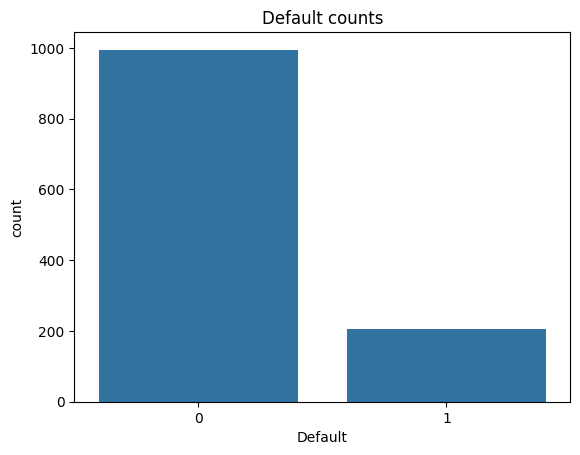

In [8]:
sns.countplot(x='Default', data=data)
plt.title('Default counts')
plt.show()


### label encoding
Label encoding is a way of converting text categories into numbers, since machine learning models can't understand text directly — they only work with numbers.

Employment_Type and Education are text categories, converting them to numbers so model can use them

In [9]:
data['Employment_Type'].unique()


<StringArray>
['Self-Employed', 'Business', 'Salaried']
Length: 3, dtype: str

In [10]:
data['Education'].unique()


<StringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str

This creates two `LabelEncoder` objects — one for `Employment_Type` and one for `Education` — since each column has different categories, each needs its own encoder. Then `fit_transform()` learns the unique categories in each column and replaces the text values with numbers. Finally, `data.head()` shows the first 5 rows so we can see the columns are now numeric instead of text.

In [11]:
le1 = LabelEncoder()
le2 = LabelEncoder()

data['Employment_Type'] = le1.fit_transform(data['Employment_Type'])
data['Education'] = le2.fit_transform(data['Education'])

data.head()


,Age,Annual_Income,Employment_Type,Education,Loan_Amount,Credit_Score,Default
0,24,133667.0,2,0,342230,675.0,0
1,55,79463.0,2,1,146983,412.0,0
2,49,147943.0,0,1,135905,338.0,0
3,40,117793.0,2,1,69362,574.0,0
4,40,102869.0,1,1,7080,766.0,0


### splitting into features (X) and target (y)
**Splitting** means dividing the dataset into two parts — a **training set** (used to teach the model) and a **testing set** (used to check how well the model performs on new, unseen data).

**Features (X):** the input columns used to make a prediction.
**Target (y):** the column we're trying to predict.

This separates the data into two parts: `X` contains all the columns except `Default` — these are the input features the model will learn from. `y` contains just the `Default` column — this is the target we're trying to predict. `X.head()` shows the first 5 rows of the features to double-check everything looks right.

In [12]:
X = data.drop(columns=['Default'])
y = data['Default']

X.head()


,Age,Annual_Income,Employment_Type,Education,Loan_Amount,Credit_Score
0,24,133667.0,2,0,342230,675.0
1,55,79463.0,2,1,146983,412.0
2,49,147943.0,0,1,135905,338.0
3,40,117793.0,2,1,69362,574.0
4,40,102869.0,1,1,7080,766.0


### train test split

80% data for training, 20% for testing
Train test split is the process of dividing the data into two parts:

Training set — used to teach/train the model
Testing set — used to check how well the model performs on data it hasn't seen before

This is done so we can fairly evaluate the model — testing it on the same data it was trained on wouldn't tell us how it performs in real situations.

This splits the data into training and testing sets using `train_test_split`. `test_size=0.2` means 20% of the data goes into testing and 80% into training. `stratify=y` makes sure both sets keep the same ratio of defaulters vs non-defaulters as the original data. `random_state=42` just makes the split reproducible, so we get the same split every time we run it. The two `print` statements then show how many rows ended up in the training set and the testing set.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)


(960, 6)
(240, 6)


### feature scaling
**Feature scaling** means adjusting numeric columns so they're all on a similar scale/range, instead of having some columns with small numbers (like Age: 20-65) and others with huge numbers (like Loan_Amount: 5000-500000). Some algorithms (like KNN and Logistic Regression) can get biased toward columns with bigger numbers if we don't do this, so we scale everything to be fair.




This creates a `StandardScaler` object, which will rescale numeric columns so they have a mean of 0 and a standard deviation of 1. `fit_transform()` on `X_train` learns the scaling values (mean, std) **from the training data** and applies them. Then `transform()` on `X_test` applies that *same* scaling to the test data — we don't `fit` again here, because the model should only ever learn from the training data, not the test data.

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### training different models

now training 4 different classification algorithms on the same data:
- Logistic Regression
- KNN
- Decision Tree
- Random Forest

then comparing all of them using same metrics

This creates a Python dictionary called `models`, where each key is the name of an algorithm (as text) and each value is that algorithm's model object, ready to be trained. This just sets up all 4 models in one place so we can loop through them easily in the next step, instead of writing separate code for each one.

In [15]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}


This is the main loop that trains and tests all 4 models:

- `results = []` — an empty list to store each model's scores.
- `for name, model in models.items():` — loops through the `models` dictionary one algorithm at a time.
- `model.fit(X_train_scaled, y_train)` — trains that model on the training data.
- `model.predict(X_test_scaled)` — uses the trained model to make predictions on the test data.
- The next 4 lines calculate **accuracy, precision, recall, and f1 score** by comparing the predictions (`y_pred`) to the actual answers (`y_test`).
- `results.append([...])` — saves the model's name and its scores into the `results` list, so we can compare all models later.
- The `print` statements just display each model's scores on screen as the loop runs.

In [16]:
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

    print(name)
    print("accuracy:", acc)
    print("precision:", prec)
    print("recall:", rec)
    print("f1 score:", f1)
    print()


Logistic Regression
accuracy: 0.8083333333333333
precision: 0.2222222222222222
recall: 0.04878048780487805
f1 score: 0.08

KNN
accuracy: 0.8041666666666667
precision: 0.2857142857142857
recall: 0.0975609756097561
f1 score: 0.14545454545454545

Decision Tree
accuracy: 0.7458333333333333
precision: 0.23684210526315788
recall: 0.21951219512195122
f1 score: 0.22784810126582278



Random Forest
accuracy: 0.8041666666666667
precision: 0.125
recall: 0.024390243902439025
f1 score: 0.04081632653061224



### comparing all models together

This takes the `results` list (which has each model's name and scores) and converts it into a pandas DataFrame called `results_df`, with proper column names — `Model`, `Accuracy`, `Precision`, `Recall`, `F1 Score`. Writing `results_df` at the end just displays this table so we can see and compare all 4 models' scores side by side.

In [17]:
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
results_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.808333,0.222222,0.048780,0.080000
1,KNN,0.804167,0.285714,0.097561,0.145455
2,Decision Tree,0.745833,0.236842,0.219512,0.227848
3,Random Forest,0.804167,0.125000,0.024390,0.040816


This creates a bar chart to visually compare all 4 models:

- `results_df.set_index('Model')` — makes the `Model` column the row labels instead of a regular column, so each bar group is labeled with the model name.
- `.plot(kind='bar', figsize=(10,6))` — draws a bar chart, with the size set to 10x6.
- `plt.title(...)` and `plt.ylabel(...)` — add a title and label the y-axis as "Score".
- `plt.xticks(rotation=0)` — keeps the model names on the x-axis horizontal (not tilted).
- `plt.legend(loc='lower right')` — places the legend (showing which color is which metric) in the bottom-right corner.
- `plt.show()` — actually displays the chart.

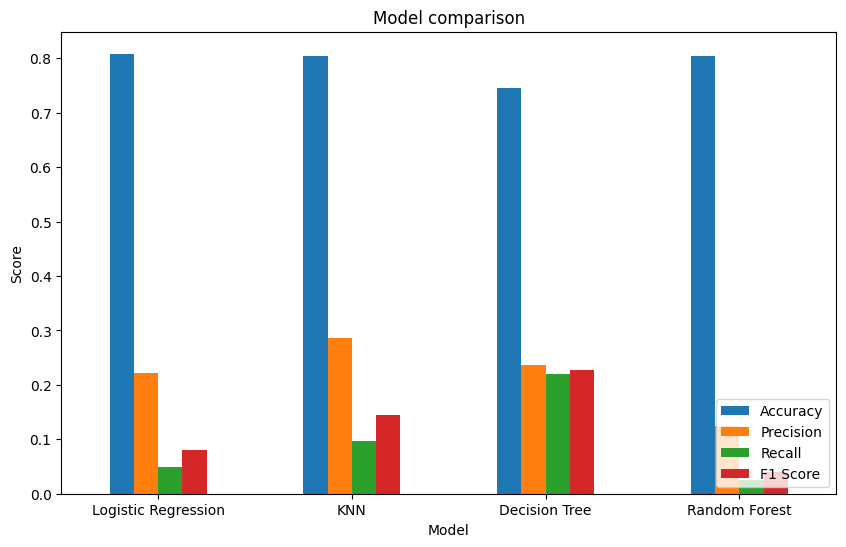

In [18]:
results_df.set_index('Model').plot(kind='bar', figsize=(10,6))
plt.title('Model comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()


**Explanation of the Graph**

The graph presents a comparison of four classification models — Logistic Regression, KNN, Decision Tree, and Random Forest — based on four evaluation metrics: Accuracy, Precision, Recall, and F1 Score.

It can be observed that all four models achieve relatively high accuracy, ranging between approximately 0.75 and 0.80. However, their Precision, Recall, and F1 Score values are considerably lower, mostly below 0.30.

This discrepancy occurs due to the class imbalance present in the dataset, where the majority of applicants did not default on their loan. As a result, a model can achieve high accuracy simply by correctly predicting the majority class (no default), without effectively identifying the minority class (actual defaulters). This explains why accuracy alone is not a reliable metric for evaluating model performance on imbalanced datasets.

Among the four models, the Decision Tree demonstrates comparatively better Precision, Recall, and F1 Score, despite having a lower accuracy than the other models. This indicates that the Decision Tree is relatively more effective at correctly identifying actual defaulters, whereas the remaining models, despite their higher accuracy, are less effective in capturing the minority class.

Overall, the graph highlights the importance of evaluating classification models using multiple metrics — particularly Precision, Recall, and F1 Score — rather than relying solely on accuracy, especially when working with imbalanced datasets.

This code identifies the best-performing model based on the F1 Score:

- `results_df.sort_values('F1 Score', ascending=False)` — sorts the results table in descending order of F1 Score, so the model with the highest F1 Score appears first.
- `.iloc[0]` — selects that first row (the best-performing model).
- `['Model']` — picks out just the model's name from that row.
- `print(...)` — displays which model was selected as the best one, based on F1 Score.

In [19]:
best_model_name = results_df.sort_values('F1 Score', ascending=False).iloc[0]['Model']
print("best model based on f1 score:", best_model_name)


best model based on f1 score: Decision Tree


### confusion matrix of best model

A **confusion matrix** is a table that shows how many predictions were correct and how many were wrong, split by class (No Default vs Default). It helps us see exactly where the model is making mistakes, not just an overall score.

This code retrieves the best model and visualizes its predictions using a confusion matrix:

- `models[best_model_name]` — looks up the actual model object from the `models` dictionary, using the best model's name found earlier.
- `best_model.predict(X_test_scaled)` — uses that model to make predictions on the test data again.
- `confusion_matrix(y_test, y_pred_best)` — compares the actual values (`y_test`) with the predicted values (`y_pred_best`) and creates a table (confusion matrix) showing correct and incorrect predictions.
- `sns.heatmap(cm, annot=True, fmt='d')` — draws this table as a heatmap, with `annot=True` showing the actual numbers on each cell, and `fmt='d'` formatting them as whole numbers.
- `plt.xlabel`, `plt.ylabel`, `plt.title` — label the axes and give the chart a title (dynamically including the best model's name).
- `plt.show()` — displays the chart.

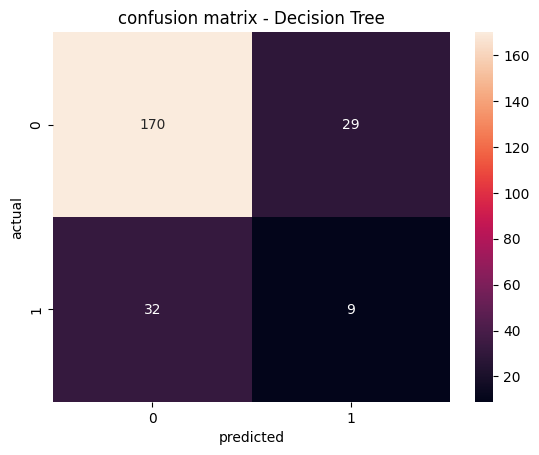

In [20]:
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title(f'confusion matrix - {best_model_name}')
plt.show()


**Conclusion**

In this project, a loan default prediction dataset was prepared by handling missing values, encoding categorical columns, and scaling numeric features. Four classification models — Logistic Regression, KNN, Decision Tree, and Random Forest — were trained and compared using accuracy, precision, recall, and F1 score. Since the dataset was imbalanced, accuracy alone was found to be misleading, and the F1 score was used to identify the best-performing model. This project demonstrates a complete classification workflow, from data preprocessing to model evaluation and comparison.